In [59]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [60]:
df=pd.read_csv('/kaggle/input/digit-recognizer/train.csv')

In [61]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [62]:
df.shape

(42000, 785)

In [63]:
df.sample(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
38185,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
32219,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
26681,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
28915,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
36214,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


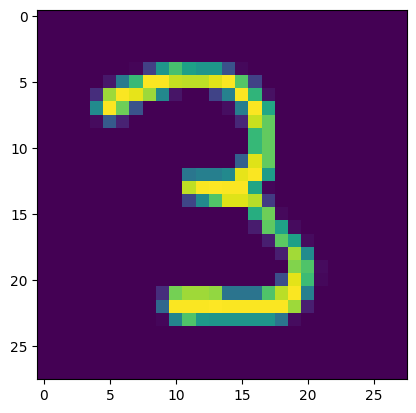

In [64]:
import matplotlib.pyplot as plt

plt.imshow(df.iloc[9148 , 1:].values.reshape(28,28))

In [65]:
X = df.iloc[:,1:]
y = df.iloc[:, 0]

In [66]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [67]:
X_train.shape

(33600, 784)

In [68]:
from sklearn.neighbors import KNeighborsClassifier

In [69]:
knn = KNeighborsClassifier()

In [70]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [71]:
import time
start= time.time()
y_pred =knn.predict(X_test)
print(time.time()- start)

10.308040857315063


In [72]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9648809523809524

By Using PCA

In [73]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [74]:
X_train= scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [92]:
# Import the PCA (Principal Component Analysis) class from scikit-learn
from sklearn.decomposition import PCA

# Create a PCA object without specifying the number of components
# n_components=None means all components are kept, and no dimensionality reduction is applied yet.
# This can be useful to analyze explained variance ratios to decide how many components to keep.
pca = PCA(n_components=None)


In [93]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)


In [94]:
X_train_trf.shape

(33600, 784)

In [95]:
knn = KNeighborsClassifier()

In [96]:
knn.fit(X_train_trf,y_train)

KNeighborsClassifier()

In [97]:
y_pred= knn.predict(X_test_trf)

In [98]:
accuracy_score(y_test,y_pred)

0.9391666666666667

In [99]:
for i in range (1,785):
    pca = PCA(n_components=i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)

    knn = KNeighborsClassifier()
    knn.fit(X_train_trf,y_train)
    y_pred= knn.predict(X_test_trf)
    print (accuracy_score(y_test,y_pred))

0.25916666666666666
0.3236904761904762
0.5104761904761905
0.6660714285714285
0.7378571428571429
0.8226190476190476
0.8439285714285715
0.8720238095238095
0.8857142857142857
0.9052380952380953
0.9114285714285715
0.9183333333333333
0.9278571428571428
0.9352380952380952
0.9384523809523809
0.9389285714285714
0.94
0.9401190476190476
0.9435714285714286
0.9434523809523809
0.9435714285714286
0.944047619047619
0.9448809523809524
0.9457142857142857
0.9483333333333334
0.9476190476190476
0.9467857142857142
0.9476190476190476
0.9501190476190476
0.9501190476190476
0.9497619047619048
0.9501190476190476
0.9497619047619048
0.9511904761904761
0.9522619047619048
0.950952380952381
0.9526190476190476
0.9529761904761904
0.9533333333333334
0.9511904761904761
0.9515476190476191
0.9508333333333333
0.9528571428571428
0.9533333333333334
0.9535714285714286
0.9536904761904762
0.9532142857142857
0.9545238095238096
0.9544047619047619
0.9536904761904762
0.9539285714285715
0.9542857142857143
0.9542857142857143
0.954523

In [101]:
#transforming to a 2D coordinate system

pca=PCA(n_components =2)
X_train_trf =pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)


In [102]:
X_train_trf

array([[-2.7186301 , -0.489868  ],
       [-0.67698892, -6.75344553],
       [-3.03322546,  6.50961698],
       ...,
       [ 2.14883017,  0.78076106],
       [ 1.05957919,  0.94752509],
       [17.70257868,  1.96231173]])

In [103]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0],
                 y=X_train_trf[:,1],
                 color =y_train_trf,
                 color_discrete_sequence = px.colors.qualitative.G10
                
                )
fig.show()

In [104]:
#transforming in 3d

pca=PCA(n_components =3)
X_train_trf =pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [105]:
X_train_trf

array([[-2.71862637, -0.48972792,  1.13586288],
       [-0.67693515, -6.7544794 , -2.33617165],
       [-3.0332826 ,  6.51091073,  7.49215816],
       ...,
       [ 2.14875258,  0.78194213, -0.74798207],
       [ 1.05958773,  0.9473539 ,  3.94998892],
       [17.70264967,  1.96036542, -4.94373377]])

In [106]:
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df,
                    x=X_train_trf[:,0],
                 y=X_train_trf[:,1],
                    z= X_train_trf[:,2],
                 color =y_train_trf
                )
fig.update_layout(
    margin =dict(l=20, r=20, t=20, b=20)
)
fig.show()

In [107]:
pca.explained_variance_ #Eigen values

array([40.67111197, 29.17023297, 26.74459588])

In [109]:
pca.components_  #eigen vectors

array([[ 2.17062797e-18, -6.19891611e-20, -5.88523314e-19, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [-2.64934333e-17,  1.71982983e-19, -9.06668551e-19, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [ 2.35810714e-17, -2.29573244e-18, -1.02806322e-17, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [110]:
pca.components_.shape  

(3, 784)

In [112]:
pca.explained_variance_ratio_ 

array([0.05785192, 0.0414927 , 0.03804239])

In [113]:
np.cumsum(pca.explained_variance_ratio_ )

array([0.05785192, 0.09934462, 0.13738701])

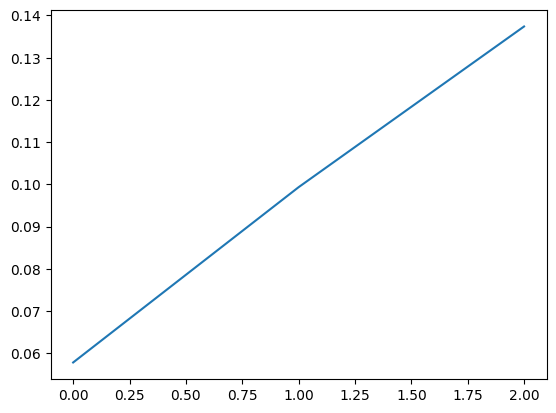

In [115]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

When PCA doesnt work?

1. If the data is allined in such a way in which variance across all axis is equal or alomost equal.
2. If the projection of the data cannot me measued and is overlapping then reasult of PCA is not quiet fruitfull. Mathematically, y=x^2

